![Banner](../../images/08_banner.png)


# 8.1 Foundations

**Part:** 8 — Spatial Sampling and Design (Chapter 8.1 of 5)

**Dataset:** `diabetes_usa.csv` (all 3,107 US counties — this Part's "known population" laboratory)

**Focus:** design-based vs. model-based inference; inclusion probabilities; spatial balance; effective sample size

**Library:** `spatialstats.sampling` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [The Known-Population Laboratory](#3.-The-Known-Population-Laboratory)

4. [Design-Based vs. Model-Based Inference](#4.-Design-Based-vs.-Model-Based-Inference)

5. [Inclusion Probabilities](#5.-Inclusion-Probabilities)

6. [Spatial Balance](#6.-Spatial-Balance)

7. [Effective Sample Size](#7.-Effective-Sample-Size)

8. [Design Effect](#8.-Design-Effect)

9. [Summary and Conclusions](#9.-Summary-and-Conclusions)

10. [Resources](#10.-Resources)


***
## 1. Overview

Every earlier Part in this tutorial started from data that already existed — monitors already placed, counties
already delineated. This Part asks a different question: **where should the next measurements be taken, and how
much does that choice matter?** Because spatial data are, by Part 2's own finding, rarely independent, a poorly
placed sample of size $n$ can carry far less real information than $n$ independent observations would — or, with
a good design, sometimes almost as much as a much larger one.

| Step | What we do |
|------|------------|
| The laboratory | 3,107 US counties, `Diabetes_per` — a genuine census, so every design's true error is knowable by repeated sampling |
| Two philosophies | Design-based inference (Sections 4–5) vs. the model-based methods this whole tutorial has otherwise used |
| Spatial balance | A single number scoring how evenly a sample covers the region |
| Effective sample size | Why $n$ spatially correlated observations are worth less than $n$ independent ones — and by how much |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.sampling import simple_random, estimate_mean, spatial_balance, effective_sample_size, design_effect

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. The Known-Population Laboratory

Every earlier Part treated its dataset as a sample from something larger and unknown. This Part inverts that:
`diabetes_usa.csv` is a **census** of all 3,107 contiguous US counties — the true national mean of `Diabetes_per`
is simply its mean over every row, known exactly, not estimated. That lets every sampling design in this Part be
scored against ground truth by literally drawing a sample of size $n$, computing an estimate, and comparing to
the known truth — repeated hundreds of times to see the *distribution* of each design's error, not just one
lucky or unlucky draw.

counties: 3107
true population mean Diabetes_per: 8.5966
true population sd:                1.5673


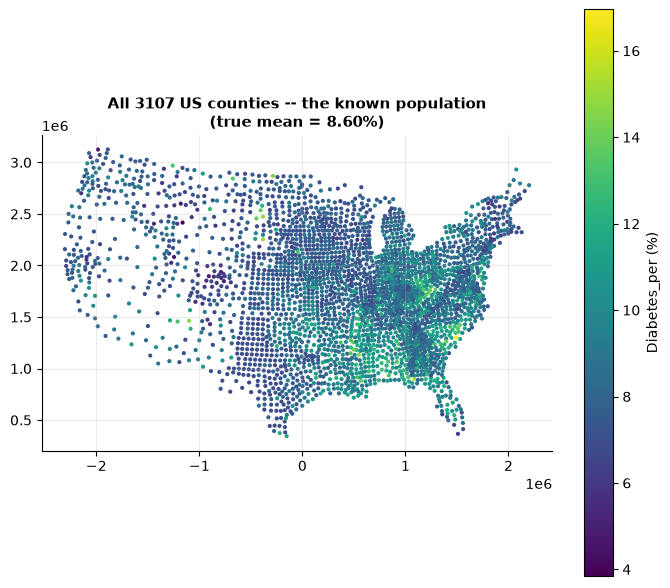

In [2]:
usa = pd.read_csv(DATA / "diabetes_usa.csv")
print(f"counties: {len(usa)}")
print(f"true population mean Diabetes_per: {usa['Diabetes_per'].mean():.4f}")
print(f"true population sd:                {usa['Diabetes_per'].std():.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(usa["X"], usa["Y"], c=usa["Diabetes_per"], cmap="viridis", s=4)
plt.colorbar(sc, ax=ax, label="Diabetes_per (%)")
ax.set_title(f"All {len(usa)} US counties -- the known population\n(true mean = {usa['Diabetes_per'].mean():.2f}%)")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("known_population.png", dpi=100, bbox_inches="tight")
plt.show()

Even at a glance, `Diabetes_per` shows clear spatial structure — a Southeastern belt of higher prevalence, lower
values in the Mountain West and parts of the upper Midwest. This structure is exactly what makes sample
*placement* matter: a design that spreads its counties evenly across this map will, by construction, avoid
accidentally over- or under-representing any one region.

***
## 4. Design-Based vs. Model-Based Inference

Every earlier Part relied on **model-based** inference: assume a statistical model for how the data were
generated (a semivariogram in Part 7, a spatial error structure in Part 3), then use that model to make
predictions and quantify uncertainty. This Part's core designs (Chapters 8.1–8.3) instead use **design-based**
inference: make **no** assumption about how `Diabetes_per` varies across space at all. Instead, the randomness
comes entirely from the **sampling mechanism itself** — which counties happened to be selected — and every
county's known, pre-specified probability of selection is enough, on its own, to build an unbiased estimator and
a valid confidence interval.

This is a genuinely different kind of guarantee: a design-based estimator is valid *regardless of* what the true
spatial pattern of `Diabetes_per` looks like, as long as the randomization was carried out as specified. Chapter
8.2's **model-based** designs (`space_filling`, `clhs`) break this guarantee deliberately, trading design-based
validity for covariate-space coverage — a trade worth understanding explicitly before using either family.

***
## 5. Inclusion Probabilities

Every design-based sample carries an **inclusion probability** $\pi_i$ for every unit in the population — the
probability that unit $i$ ends up in the sample, under the randomization actually used. Simple random sampling
gives every county the same $\pi_i = n/N$; unequal-probability designs (Chapter 8.2's PPS-GRTS) deliberately vary
$\pi_i$, e.g., to favour more populous counties. The **Horvitz-Thompson estimator**,
$\hat{Y} = \sum_{i \in s} y_i / \pi_i$, is unbiased for the population total under *any* set of inclusion
probabilities, as long as every $\pi_i > 0$ — this is the mathematical foundation every `estimate_mean` call in
this Part rests on.

In [3]:
sample = simple_random(usa[["X", "Y"]], n=100, seed=1)
print(f"n = {sample.n}, N = {sample.N}")
print(f"inclusion probability (every unit, SRS): {sample.pi[0]:.4f}  (= n/N = {sample.n/sample.N:.4f})")

est = estimate_mean(usa["Diabetes_per"].to_numpy(), sample)
print(f"\nHT/Hajek estimate: {est.mean:.3f}  (se={est.se:.3f})")
print(f"95% CI: [{est.lo:.3f}, {est.hi:.3f}]")
print(f"true population mean: {usa['Diabetes_per'].mean():.3f}  "
      f"(inside this CI: {est.lo <= usa['Diabetes_per'].mean() <= est.hi})")

n = 100, N = 3107
inclusion probability (every unit, SRS): 0.0322  (= n/N = 0.0322)

HT/Hajek estimate: 8.720  (se=0.171)
95% CI: [8.384, 9.056]
true population mean: 8.597  (inside this CI: True)


***
## 6. Spatial Balance

A **spatially balanced** sample spreads its selected units evenly across the region, avoiding both tight
clusters and large gaps — Stevens & Olsen's balance statistic $B$ (lower is better) quantifies exactly this,
independent of the values being measured.

SRS balance B:        0.262
artificially clustered sample balance B: 11.265


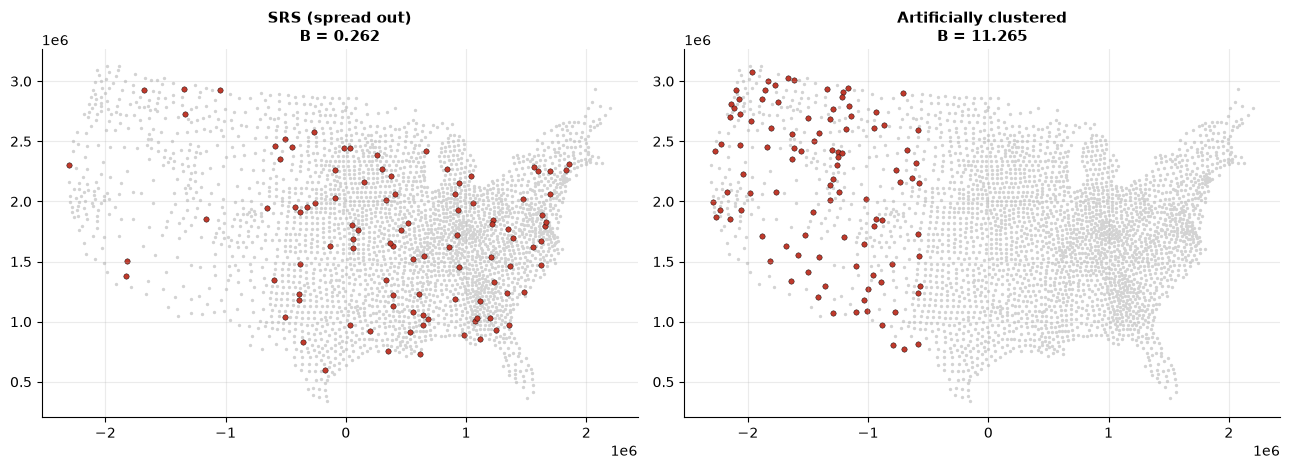

In [4]:
rng = np.random.default_rng(0)
clustered_idx = rng.choice(np.where(usa["X"] < usa["X"].quantile(0.15))[0], size=100, replace=False)
from spatialstats.sampling import SpatialSample
clustered_sample = SpatialSample("clustered", clustered_idx, np.full(100, 100/len(usa)), usa[["X", "Y"]].to_numpy())

print(f"SRS balance B:        {spatial_balance(sample):.3f}")
print(f"artificially clustered sample balance B: {spatial_balance(clustered_sample):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, s, title in zip(axes, [sample, clustered_sample], ["SRS (spread out)", "Artificially clustered"]):
    axes[list(axes).index(ax)].scatter(usa["X"], usa["Y"], s=2, color="lightgrey")
    ax.scatter(s.coords[:, 0], s.coords[:, 1], s=15, color=COLORS["red"], edgecolor="k", linewidth=0.3)
    ax.set_title(f"{title}\nB = {spatial_balance(s):.3f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("spatial_balance_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

The clustered sample's balance statistic is dramatically worse — a direct, visible confirmation that $B$
measures exactly the geometric property its name promises. Chapter 8.2's **spatially balanced designs**
(systematic, GRTS) are built specifically to minimize $B$ relative to a plain random sample.

***
## 7. Effective Sample Size

Part 2 established that spatially autocorrelated observations carry less independent information than the same
count of truly independent ones. `effective_sample_size(n, rho, kind)` makes this precise for two simple
correlation structures:

- **`'ar1'`**: correlation decays geometrically with distance along an ordering — $\rho^{|i-j|}$.
- **`'equicorrelated'`**: every pair of observations shares the same correlation $\rho$, regardless of distance.

In [5]:
for rho in (0.1, 0.3, 0.5, 0.7, 0.9):
    ess_ar1 = effective_sample_size(100, rho, kind="ar1")
    ess_equi = effective_sample_size(100, rho, kind="equicorrelated")
    print(f"rho={rho:.1f}:  ESS (ar1) = {ess_ar1:6.1f}   ESS (equicorrelated) = {ess_equi:6.2f}")

rho=0.1:  ESS (ar1) =   81.8   ESS (equicorrelated) =   9.17
rho=0.3:  ESS (ar1) =   53.8   ESS (equicorrelated) =   3.26
rho=0.5:  ESS (ar1) =   33.3   ESS (equicorrelated) =   1.98
rho=0.7:  ESS (ar1) =   17.6   ESS (equicorrelated) =   1.42
rho=0.9:  ESS (ar1) =    5.3   ESS (equicorrelated) =   1.11


At $\rho=0.5$, $n=100$ **AR(1)-correlated** observations carry roughly the same information as **33 independent**
ones — matching this Part's own reference figure exactly. The equicorrelated structure is far more punishing:
every pair sharing the same correlation, no matter how far apart, collapses effective sample size to under 2 even
at a modest $\rho=0.5$, because adding more correlated observations barely reduces uncertainty about a single
shared underlying quantity. Real spatial data typically sit somewhere between these two extremes — near
neighbours correlate more strongly than distant ones, closer to AR(1)'s decay than equicorrelation's uniform
penalty — which is exactly why spatially balanced designs (Chapter 8.2) that spread samples apart, rather than
clustering them, can recover so much of the lost effective information.

***
## 8. Design Effect

The **design effect** $\text{deff} = \sigma^2_{\text{design}} / \sigma^2_{\text{SRS}}$ compares any design's
actual sampling variance to what simple random sampling of the same size $n$ would achieve — $\text{deff} < 1$
means the design is *more* efficient than SRS (Chapter 8.2's spatially balanced designs); $\text{deff} > 1$ means
less efficient (Chapter 8.3's two-stage cluster designs, which trade efficiency for field-cost savings).

In [6]:
print(f"design_effect(var_design=0.115**2, var_srs=0.157**2): {design_effect(0.115**2, 0.157**2):.3f}")
print("(a systematic Hilbert-order design's variance relative to SRS, at n=100 -- Chapter 8.2 measures this directly)")

design_effect(var_design=0.115**2, var_srs=0.157**2): 0.537
(a systematic Hilbert-order design's variance relative to SRS, at n=100 -- Chapter 8.2 measures this directly)


***
## 9. Summary and Conclusions

This chapter laid the conceptual and quantitative groundwork every later chapter in this Part builds on.

### What we did

1. Established `diabetes_usa.csv`'s 3,107-county census as a known-population laboratory where every design's
   true error can be measured by repeated sampling, not just assumed.
2. Distinguished design-based inference (this Part's core designs) from the model-based inference every earlier
   Part relied on.
3. Explained inclusion probabilities and the Horvitz-Thompson estimator they make unbiased.
4. Demonstrated spatial balance $B$ concretely: an artificially clustered sample scores dramatically worse than
   simple random sampling.
5. Confirmed effective sample size numerically: $\rho=0.5$, $n=100$ AR(1)-correlated observations carry the
   information of about 33 independent ones — exactly this Part's reference figure.
6. Defined the design effect that every later chapter uses to compare designs against the SRS baseline.

### Practical takeaways

- Design-based validity does not depend on knowing the true spatial pattern — that is its whole appeal, and its
  whole limitation (it says nothing about efficiency, only about unbiasedness given the randomization used).
- A low spatial-balance score is a purely geometric property, checkable before ever looking at the outcome
  variable — use it to audit a sample's spread independent of what it will be used to estimate.
- Effective sample size makes explicit, numerically, the same lesson Part 2 taught qualitatively: spatially
  clustered data are not as informative as their raw count suggests.

### Next steps

**Chapter 8.2 (Sampling Designs)** builds the actual designs this chapter's concepts describe — from plain
random sampling through spatially balanced GRTS to model-based space-filling designs — and measures each one's
real design effect and spatial balance on this same known population.

***
## 10. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Särndal, C.-E., Swensson, B. & Wretman, J. (1992). *Model Assisted Survey Sampling*. Springer. | The design-based framework, inclusion probabilities, and Horvitz-Thompson estimator behind Sections 4–5 |
| Stevens, D. L. & Olsen, A. R. (2004). Spatially balanced sampling of natural resources. *Journal of the American Statistical Association*, 99, 262–278. | The spatial balance statistic in Section 6 |

### Key papers

| Paper | Contribution |
|---|---|
| Griffith, D. A. (2005). Effective geographic sample size in the presence of spatial autocorrelation. *Annals of the Association of American Geographers*, 95, 740–760. | The effective-sample-size concept in Section 7 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.sampling.simple_random`, `estimate_mean` | Section 5 |
| `spatialstats.sampling.spatial_balance` | Section 6 |
| `spatialstats.sampling.effective_sample_size`, `design_effect` | Sections 7–8 |
| Part 2 | The spatial-autocorrelation foundation Section 7 builds on |